In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu, shapiro

In [2]:
df = pd.read_csv('product_revenue.csv')
df.head()

,control_group,test_group
0,66.243454,47.748632
1,43.882436,53.155998
2,44.718282,21.957059
3,39.270314,78.604062
4,58.654076,27.098466


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   control_group  100 non-null    float64
 1   test_group     100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


,control_group,test_group
count,100.000000,100.000000
mean,50.605829,52.443883
std,8.896155,15.633903
min,26.984613,14.108258
25%,43.861825,43.571634
50%,50.640739,53.019468
75%,56.374103,62.098228
max,71.855754,88.383120


In [4]:
control_mean = df['control_group'].mean()
test_mean = df['test_group'].mean()

print("Control mean:", round(control_mean, 2))
print("Test mean:", round(test_mean, 2))

Control mean: 50.61
Test mean: 52.44


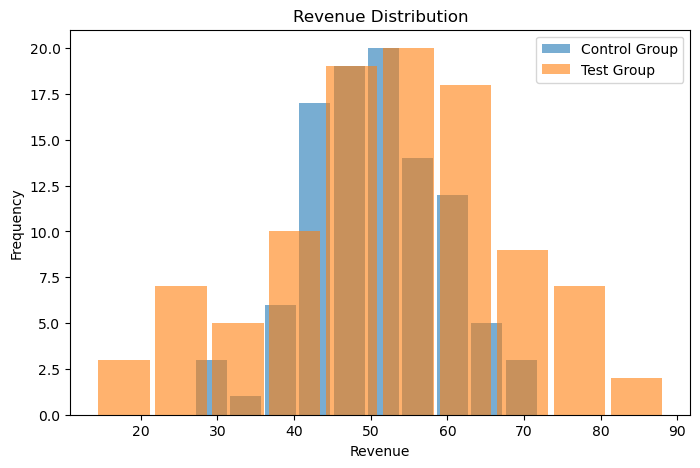

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df['control_group'], alpha=0.6, rwidth=0.9, label='Control Group')
plt.hist(df['test_group'], alpha=0.6, rwidth=0.9, label='Test Group')
plt.legend()
plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

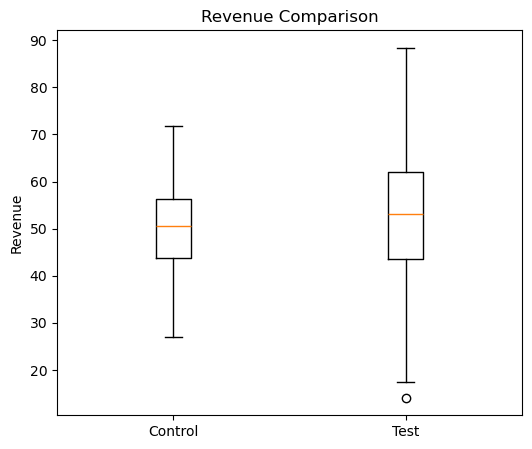

In [14]:
plt.figure(figsize=(6,5))

plt.boxplot([df['control_group'], df['test_group']],
            tick_labels=['Control', 'Test'])

plt.title('Revenue Comparison')
plt.ylabel('Revenue')

plt.show()

In [ ]:
-- Normality test

In [9]:
control_shapiro = shapiro(df['control_group'])
test_shapiro = shapiro(df['test_group'])

print("Control p-value:", control_shapiro.pvalue)
print("Test p-value:", test_shapiro.pvalue)

Control p-value: 0.821545185759351
Test p-value: 0.5677973106824004


In [ ]:
-- T-test

In [10]:
t_stat, p_value = ttest_ind(df['control_group'], df['test_group'])

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -1.02183466794158
P-value: 0.30810601656951186


In [ ]:
-- Mann-Whitney

In [11]:
u_stat, mw_p = mannwhitneyu(df['control_group'], df['test_group'])

print("Mann-Whitney U:", u_stat)
print("P-value:", mw_p)

Mann-Whitney U: 4409.0
P-value: 0.14907086303735595


In [ ]:
-- Confidence interval

In [12]:
mean_diff = test_mean - control_mean
std_error = np.sqrt(
    df['control_group'].var()/len(df) +
    df['test_group'].var()/len(df)
)

ci_low = mean_diff - 1.96 * std_error
ci_high = mean_diff + 1.96 * std_error

print("95% CI:", ci_low, ci_high)

95% CI: -1.6875518485974066 5.363660789997409
